**Step1**:Load the data and inspect the basics

In [1]:
#import libraries
import pandas as pd

In [2]:
df=pd.read_csv('data/online_shoppers_intention.csv')

In [3]:
print(df.shape)
print(df.head())


(12330, 18)
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0         

In [4]:
print(df.info())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
print(df["Revenue"].value_counts())
print(df["Revenue"].value_counts(normalize=True))

Revenue
False    10422
True      1908
Name: count, dtype: int64
Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64


Insight:
* Dataset size: 12,330 rows × 18 columns
* Missing values: none
* Revenue is highly imbalanced
    * False: 10,422
    * True: 1,908
* purchase rate: about 15.47%
* Data types look clean:
* numeric variables are ready
* Month and VisitorType are categorical text
* Weekend and Revenue are boolean

That means the data is in good shape and we can move to EDA.

**Step 2**: Summary statistics for numeric variables

In [6]:
numeric_cols= [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay"
]
print(df[numeric_cols].describe().T)

                           count         mean          std  min         25%  \
Administrative           12330.0     2.315166     3.321784  0.0    0.000000   
Administrative_Duration  12330.0    80.818611   176.779107  0.0    0.000000   
Informational            12330.0     0.503569     1.270156  0.0    0.000000   
Informational_Duration   12330.0    34.472398   140.749294  0.0    0.000000   
ProductRelated           12330.0    31.731468    44.475503  0.0    7.000000   
ProductRelated_Duration  12330.0  1194.746220  1913.669288  0.0  184.137500   
BounceRates              12330.0     0.022191     0.048488  0.0    0.000000   
ExitRates                12330.0     0.043073     0.048597  0.0    0.014286   
PageValues               12330.0     5.889258    18.568437  0.0    0.000000   
SpecialDay               12330.0     0.061427     0.198917  0.0    0.000000   

                                50%          75%           max  
Administrative             1.000000     4.000000     27.000000  


Insights:
A few important things already stand out:
* Many variables are right_skewed
* Several have lots of zeros,especially:
  
       * Informational
       * Informational_Duration
       * PageValues
       *  SpecialDay
* Some variables have very large ranges,especially:

       * ProductRelated_Duration
       * Administrative _Duration
       * PageValues

So later, scaling will definitely matter for clustering!!  

**Step 3**: Compare numeric variables by Revenue

Now let’s see whether buyers and non-buyers behave differently.

In [7]:
revenue_summary = df.groupby("Revenue")[numeric_cols].mean().T
print(revenue_summary)

Revenue                        False        True 
Administrative              2.117732     3.393606
Administrative_Duration    73.740111   119.483244
Informational               0.451833     0.786164
Informational_Duration     30.236237    57.611427
ProductRelated             28.714642    48.210168
ProductRelated_Duration  1069.987809  1876.209615
BounceRates                 0.025317     0.005117
ExitRates                   0.047378     0.019555
PageValues                  1.975998    27.264518
SpecialDay                  0.068432     0.023166


In [8]:
revenue_summary["difference_True_minus_False"] = revenue_summary[True] - revenue_summary[False]
print(revenue_summary.sort_values("difference_True_minus_False", ascending=False))

Revenue                        False         True  difference_True_minus_False
ProductRelated_Duration  1069.987809  1876.209615                   806.221806
Administrative_Duration    73.740111   119.483244                    45.743133
Informational_Duration     30.236237    57.611427                    27.375189
PageValues                  1.975998    27.264518                    25.288520
ProductRelated             28.714642    48.210168                    19.495526
Administrative              2.117732     3.393606                     1.275874
Informational               0.451833     0.786164                     0.334331
BounceRates                 0.025317     0.005117                    -0.020200
ExitRates                   0.047378     0.019555                    -0.027823
SpecialDay                  0.068432     0.023166                    -0.045267


Users who purchase (revenue=True) tend to have: 
* Much higher ProductRelated_Duration
* Higher Administrative_Duration
* Higher Informational_Duration
* much higher PageValues
* more ProductRelated pages visited 

And purchasers tend to have lower: 
* BonusRates
* ExitRates

Especially important:
* PageValues looks highly different between buyers and non-buyers
* ProductRelated_Duration is also a major separator
* BounceRates/ExitRates move in the opposite direction,which makes intuitive sense

Step 4: Correlation with Revenue


Now let's quantify that a little

In [9]:
df_corr=df[numeric_cols+["Revenue"]].copy()
df_corr["Revenue"]=df_corr["Revenue"].astype(int)

corr_with_revenue=df_corr.corr()["Revenue"].sort_values(ascending=False)
print(corr_with_revenue)

Revenue                    1.000000
PageValues                 0.492569
ProductRelated             0.158538
ProductRelated_Duration    0.152373
Administrative             0.138917
Informational              0.095200
Administrative_Duration    0.093587
Informational_Duration     0.070345
SpecialDay                -0.082305
BounceRates               -0.150673
ExitRates                 -0.207071
Name: Revenue, dtype: float64


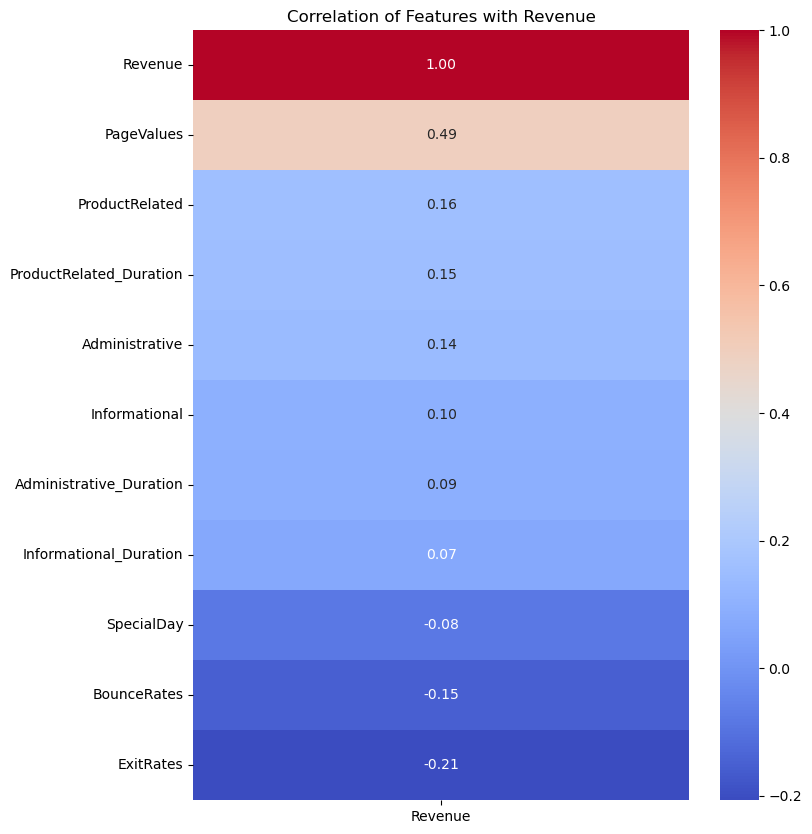

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlation and sort it
# We use [['Revenue']] to keep it as a DataFrame for seaborn
revenue_corr = df_corr.corr()[['Revenue']].sort_values(by='Revenue', ascending=False)

# 2. Plot the heatmap
plt.figure(figsize=(8, 10))
sns.heatmap(revenue_corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation of Features with Revenue')
plt.show()

Based on the results above , the variables most associated with purchase behavior are:
* PageValues has the strongest positive relationship
* ProductRelated
* ProductRelated_Duration
* Then smaller positive relationship from:
    * Administrative 
    * Informational
    * their duration variables
* Negative relationships:
    * ExitRates
    * BounceRates
This lines up with Step 3 and gives us nice material to talk about for the report 

**Step 5:** Check categorical variables vs Revenue 

Now let’s check if purchase behavior differs across categorical features.

In [11]:
categorical_cols=[
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]
for col in categorical_cols:
    print(f"\n---{col}---")
    print(pd.crosstab(df[col],df["Revenue"],normalize="index"))



---Month---
Revenue     False     True 
Month                      
Aug      0.824480  0.175520
Dec      0.874928  0.125072
Feb      0.983696  0.016304
Jul      0.847222  0.152778
June     0.899306  0.100694
Mar      0.899318  0.100682
May      0.891498  0.108502
Nov      0.746498  0.253502
Oct      0.790528  0.209472
Sep      0.808036  0.191964

---OperatingSystems---
Revenue              False     True 
OperatingSystems                    
1                 0.853385  0.146615
2                 0.825027  0.174973
3                 0.895108  0.104892
4                 0.822176  0.177824
5                 0.833333  0.166667
6                 0.894737  0.105263
7                 0.857143  0.142857
8                 0.784810  0.215190

---Browser---
Revenue     False     True 
Browser                    
1        0.851747  0.148253
2        0.846376  0.153624
3        0.952381  0.047619
4        0.823370  0.176630
5        0.815846  0.184154
6        0.885057  0.114943
7        0.877551 

Insights:

* Month matters a lot:
    * Nov has a much higher purchase rate
    * May/Oct/Sep/July/Dec also look stronger than Feb
* Weekend=True has a slightly higher purchase rate than weekday
* VisitorType is intereseting:
    * New_Visitor has a higher purchase rate than Returning_Visitor
* Some TrafficType groups look very different, though a few may have small counts 

Take away: This supports keeping the categorical variables in the clustering, because they likely add useful behavioral context beyond the numeric variables.

**Step 6**: Prepare data for clustering


Now we can create the modeling dataset. 

    We will :
* Remove Revenue from clustering input
* One-hot encode categorical variables
* Standardize numeric variables


In [14]:
#import libraries
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

#Seprate features and Target
X=df.drop(columns=["Revenue"])
y=df["Revenue"] #We will keep it for later evaluation, not for clustering

#NUmeric columns
numeric_cols= [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay"
]
# Categorical columns
categorical_cols=[
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

# ColumnsTransformer:
#StandardScaler for numeric columns
#OnehotEncoder for categorical columns

preprocessor = make_column_transformer(
    (StandardScaler(), numeric_cols),
    (OneHotEncoder(drop=None, sparse_output=False, handle_unknown="ignore"), categorical_cols)
)
#Fit and Transform the features
X_processed=preprocessor.fit_transform(X)

print("Processed shape:",X_processed.shape)


Processed shape: (12330, 75)


In [15]:
#Since make_column_transformer auto-generates names:
preprocessor

,transformers,"[('standardscaler', ...), ('onehotencoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [16]:
feature_names = preprocessor.get_feature_names_out()

print("Total features after encoding:", len(feature_names))
print("First 20 feature names:")
print(feature_names[:20])

Total features after encoding: 75
First 20 feature names:
['standardscaler__Administrative'
 'standardscaler__Administrative_Duration' 'standardscaler__Informational'
 'standardscaler__Informational_Duration' 'standardscaler__ProductRelated'
 'standardscaler__ProductRelated_Duration' 'standardscaler__BounceRates'
 'standardscaler__ExitRates' 'standardscaler__PageValues'
 'standardscaler__SpecialDay' 'onehotencoder__Month_Aug'
 'onehotencoder__Month_Dec' 'onehotencoder__Month_Feb'
 'onehotencoder__Month_Jul' 'onehotencoder__Month_June'
 'onehotencoder__Month_Mar' 'onehotencoder__Month_May'
 'onehotencoder__Month_Nov' 'onehotencoder__Month_Oct'
 'onehotencoder__Month_Sep']


After encoding and scaling, our data became 12,330 × 75. So we now have the final feature matrix for clustering
The feature names also look correct

**Step 7:** K-means baseline model selection


We need to try severl vales of k and compare them using: 
* inertia: lower is better, but it almost always drops as k increases
* silhiouette score: higher is better, and it helps us judge cluster separations.


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans_results=[]
for k in range(2,9):
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    cluster_labels=kmeans.fit_predict(X_processed)
    inertia=kmeans.inertia_
    silhouette=silhouette_score(X_processed,cluster_labels)

    kmeans_results.append({
        "k":k,
        "inertia":inertia,
        "silhouette_score":silhouette
    })
    kmeans_results_df=pd.DataFrame(kmeans_results)
    print(kmeans_results_df)

   k        inertia  silhouette_score
0  2  151104.404442          0.302244
   k        inertia  silhouette_score
0  2  151104.404442          0.302244
1  3  131368.173359          0.284861
   k        inertia  silhouette_score
0  2  151104.404442          0.302244
1  3  131368.173359          0.284861
2  4  120979.254195          0.242567
   k        inertia  silhouette_score
0  2  151104.404442          0.302244
1  3  131368.173359          0.284861
2  4  120979.254195          0.242567
3  5  113218.785407          0.211753
   k        inertia  silhouette_score
0  2  151104.404442          0.302244
1  3  131368.173359          0.284861
2  4  120979.254195          0.242567
3  5  113218.785407          0.211753
4  6  106283.656748          0.214717
   k        inertia  silhouette_score
0  2  151104.404442          0.302244
1  3  131368.173359          0.284861
2  4  120979.254195          0.242567
3  5  113218.785407          0.211753
4  6  106283.656748          0.214717
5  7  100414

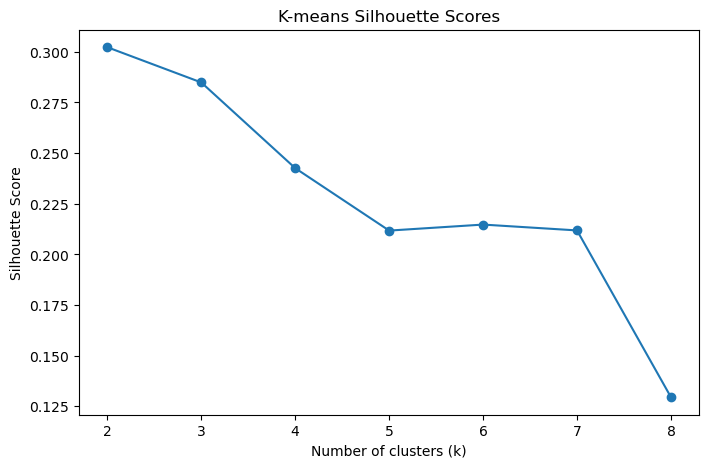

In [18]:
#To plot the results
plt.figure(figsize=(8,5))
plt.plot(kmeans_results_df["k"], kmeans_results_df["silhouette_score"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-means Silhouette Scores")
plt.show()

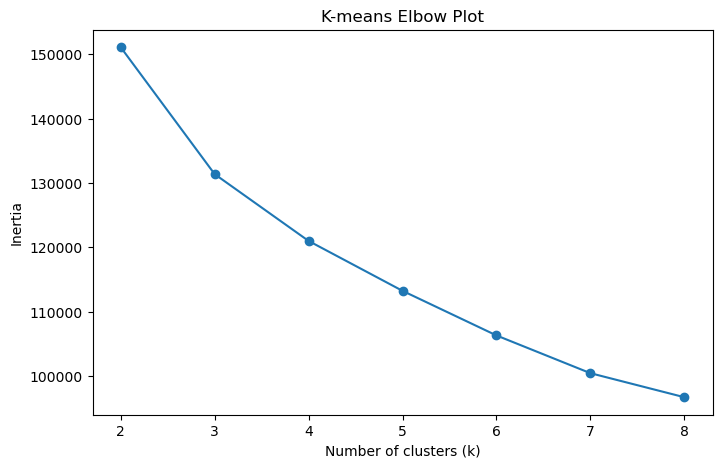

In [19]:


plt.figure(figsize=(8,5))
plt.plot(kmeans_results_df["k"], kmeans_results_df["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-means Elbow Plot")
plt.show()

Insight: There is a big drop from 2 to 3, and after that the curve starts flattening noticeably. Based on silhouette score, k=2 gives the strongest separation. However, the elbow plot suggests that k=3 is also a reasonable candidate before the marginal gain starts to flatten. Therefore, I would examine both k=2 and k=3, and keep k=2 as the strict baseline while checking whether k=3 provides more interpretable customer segments.

**Step 8 revised:** Fit both K-means solutions


In [20]:
kmeans_2=KMeans(n_clusters=2,random_state=42,n_init=10)
df["KMeans_2"]=kmeans_2.fit_predict(X_processed)

print("KMeans k=2 cluster counts:")
print(df["KMeans_2"].value_counts())
print("\nKMeans k=2 revenue mean by cluster:")

print(df.groupby("KMeans_2")["Revenue"].mean())

#k=3
kmeans_3=KMeans(n_clusters=3,random_state=42,n_init=10)
df["KMeans_3"]=kmeans_3.fit_predict(X_processed)

print("\nKMeans k=3 cluster counts:")
print(df["KMeans_3"].value_counts())
print("\nKMeans k=3 revenue mean by cluster:")
print(df.groupby("KMeans_3")["Revenue"].mean())

KMeans k=2 cluster counts:
KMeans_2
0    10457
1     1873
Name: count, dtype: int64

KMeans k=2 revenue mean by cluster:
KMeans_2
0    0.132638
1    0.278163
Name: Revenue, dtype: float64

KMeans k=3 cluster counts:
KMeans_3
1    9647
0    1628
2    1055
Name: count, dtype: int64

KMeans k=3 revenue mean by cluster:
KMeans_3
0    0.282555
1    0.149477
2    0.005687
Name: Revenue, dtype: float64


In [21]:
print("KMeans k=2 numeric profile")
print(df.groupby("KMeans_2")[numeric_cols + ["Revenue"]].mean().T)

print("\n\nKMeans k=3 numeric profile")
print(df.groupby("KMeans_3")[numeric_cols + ["Revenue"]].mean().T)

KMeans k=2 numeric profile
KMeans_2                          0            1
Administrative             1.437793     7.213561
Administrative_Duration   42.318187   295.767317
Informational              0.180836     2.305392
Informational_Duration     6.749016   189.252644
ProductRelated            21.004686    91.619327
ProductRelated_Duration  763.235213  3603.881619
BounceRates                0.025068     0.006129
ExitRates                  0.047353     0.019176
PageValues                 5.189597     9.795482
SpecialDay                 0.067342     0.028404
Revenue                    0.132638     0.278163


KMeans k=3 numeric profile
KMeans_3                           0           1          2
Administrative              7.365479    1.710998   0.046445
Administrative_Duration   308.572167   51.069899   1.390205
Informational               2.514742    0.217581   0.015166
Informational_Duration    212.242943    8.232814   0.086445
ProductRelated             96.824939   23.878304   3.093

Insight: 
K-means with k=2 provided the best silhouette score, but the k=3 solution offered a more interpretable behavioral segmentation, distinguishing high-intent shoppers, moderate browsers, and very low-intent visitors. Here are the details of these clusters:

* Cluster 0 → highest-intent / deep-engagement shoppers
    * very high duration values
    * high PageValues
    * purchase rate 28.26%
      
* Cluster 1 → medium / ordinary browsing group
    * moderate purchase rate 14.95%
      
* Cluster 2 → very low-intent / shallow visitors
    * very low Administrative, Informational, ProductRelated
    * high ExitRates
    * purchase rate only 0.57%

**Step 9:** GMM Model selection


Unlike K-Means, GMM:

* Allows soft cluster membership
* Allows differnt covariance structure
* May cappture overlapping customer behavior better

We will test: 
* n_components=2 to 6

covariance types:
* spherical 
* tied
* diag
* full


In [22]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
gmm_results=[]
for cov_type in ["spherical","tied","diag","full"]:
    for n in range(2,7):
        gmm=GaussianMixture(
            n_components=n,
            covariance_type=cov_type,
            random_state=42
        )
        gmm.fit(X_processed)
        labels=gmm.predict(X_processed)
        
        gmm_results.append({
            
            "covariance_type":cov_type,
            "n_components": n,
            "bic":gmm.bic(X_processed),
            "aic":gmm.aic(X_processed),
            "silhouette_score": silhouette_score(X_processed, labels)
        })
        
gmm_results_df=pd.DataFrame(gmm_results)
print(gmm_results_df.sort_values("bic"))
            

   covariance_type  n_components           bic           aic  silhouette_score
19            full             6 -4.598671e+06 -4.728925e+06         -0.006427
18            full             5 -4.416960e+06 -4.525504e+06         -0.009661
17            full             4 -4.069288e+06 -4.156122e+06         -0.004269
16            full             3 -3.948273e+06 -4.013397e+06          0.021894
13            diag             5 -3.592810e+06 -3.598404e+06         -0.035257
14            diag             6 -3.570728e+06 -3.577443e+06         -0.007465
12            diag             4 -3.126587e+06 -3.131062e+06          0.015299
11            diag             3 -2.761211e+06 -2.764565e+06          0.025016
15            full             2 -2.746301e+06 -2.789715e+06          0.056307
9             tied             6 -1.817940e+06 -1.842462e+06          0.244658
8             tied             5 -1.812703e+06 -1.836661e+06          0.240569
7             tied             4 -1.805431e+06 -1.82

In [23]:
# To check the columns names
print(gmm_results_df.columns)

Index(['covariance_type', 'n_components', 'bic', 'aic', 'silhouette_score'], dtype='object')


Plot BIC by covariance type

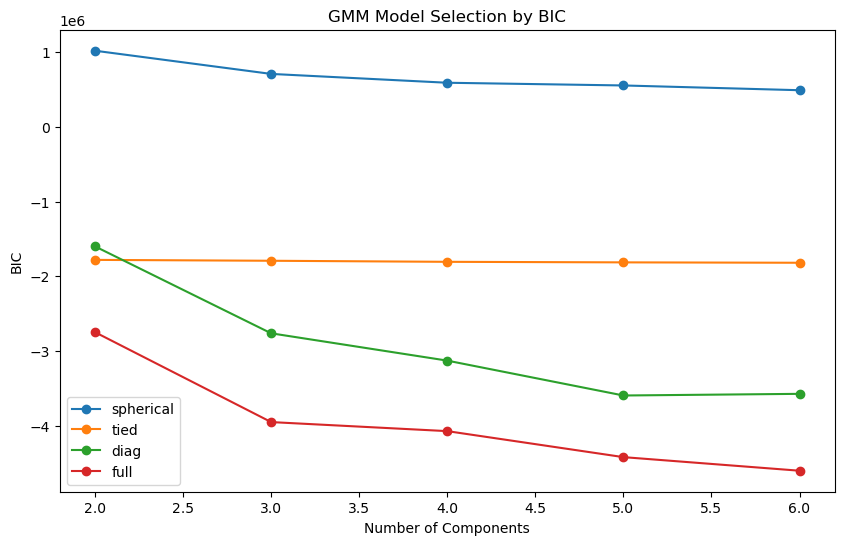

In [24]:
plt.figure(figsize=(10,6))

for cov_type in gmm_results_df["covariance_type"].unique():
    subset = gmm_results_df[gmm_results_df["covariance_type"] == cov_type]
    plt.plot(subset["n_components"], subset["bic"], marker="o", label=cov_type)

plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.title("GMM Model Selection by BIC")
plt.legend()
plt.show()

Insight: 

Based on the BIC results, the Gaussian Mixture Model with full covariance and 6 components appears to provide the best fit among the candidate models, since BIC evaluates model fit while penalizing unnecessary complexity (Bishop, 2006). This result suggests that shopper behavior in this dataset may not be well represented by simple spherical clusters, but instead may involve more complex and overlapping segment structures with different variances and correlations across features (Bishop, 2006). Given that the dataset includes behavioral variables such as page value, bounce rate, exit rate, and product-related browsing activity, this interpretation is also consistent with the richness of the original shopping-session data described by Sakar et al. (2019).

Next step: 
Since full covariance with 6 componenets is the best by BIC and tied covariance with 6 components has much better silhoette, the smartest move is to fit both and compare them before choosing the final GMM . 

**Step 10:** Fit the two cadidate GMM models


GMM full-6 cluster counts:
GMM_full_6
0    1849
1     151
2    6983
3     308
4     787
5    2252
Name: count, dtype: int64

GMM tied-6 cluster counts:
GMM_tied_6
0    1018
1    9297
2     146
3     737
4     410
5     722
Name: count, dtype: int64


<Axes: xlabel='GMM_tied_6'>

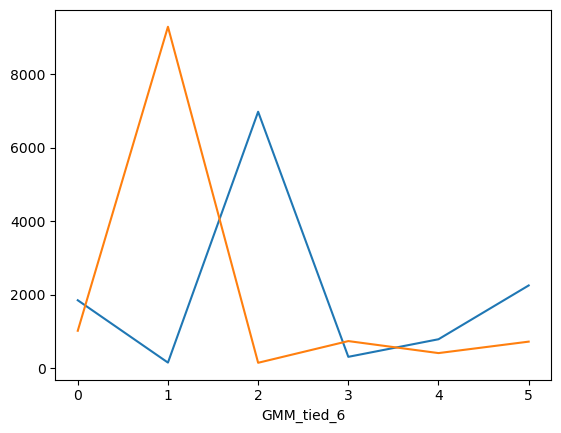

In [29]:
#from sklearn.mixture import GaussianMixture

# Best by BIC
gmm_full_6 = GaussianMixture(
    n_components=6,
    covariance_type="full",
    random_state=42
)
df["GMM_full_6"] = gmm_full_6.fit_predict(X_processed)

# Best separation among strong GMM candidates
gmm_tied_6 = GaussianMixture(
    n_components=6,
    covariance_type="tied",
    random_state=42
)
df["GMM_tied_6"] = gmm_tied_6.fit_predict(X_processed)

print("GMM full-6 cluster counts:")
print(df["GMM_full_6"].value_counts().sort_index())

df["GMM_full_6"].value_counts().sort_index().plot()

print("\nGMM tied-6 cluster counts:")
print(df["GMM_tied_6"].value_counts().sort_index())
df["GMM_tied_6"].value_counts().sort_index().plot()

**Revenue rate by cluster**:Do the clusters differ meaningfully in purchase behavior?

In [30]:
print("Revenue mean by GMM full-6 cluster:")
print(df.groupby("GMM_full_6")["Revenue"].mean().sort_values(ascending=False))

print("\nRevenue mean by GMM tied-6 cluster:")
print(df.groupby("GMM_tied_6")["Revenue"].mean().sort_values(ascending=False))

Revenue mean by GMM full-6 cluster:
GMM_full_6
4    0.270648
1    0.205298
5    0.177620
2    0.157812
0    0.086533
3    0.006494
Name: Revenue, dtype: float64

Revenue mean by GMM tied-6 cluster:
GMM_tied_6
4    0.826829
2    0.273973
5    0.254848
1    0.137786
0    0.058939
3    0.005427
Name: Revenue, dtype: float64


Insight: 
Full-6 cluster gives a nice spread from very low_intent to higher-intent groups. Especially cluster 3 looks like very low_intent /shallow cluster 
whereas cluster 4 looks like a high intent cluster with much higher PageValues and lower bounce/exit behavior. This shows that the model was able to separate very high-intent shoppers from very low-intent visitors.

For GMM-Tied-6 , we have one very high-intent cluster with exteremely high pagevalues , one very low intent cluster and a few middle groups.

**cluster profiles**: What kind of shoppers are in each cluster?

In [31]:
print("GMM full-6 numeric profile")
print(df.groupby("GMM_full_6")[numeric_cols + ["Revenue"]].mean().T)

print("\n\nGMM tied-6 numeric profile")
print(df.groupby("GMM_tied_6")[numeric_cols + ["Revenue"]].mean().T)

GMM full-6 numeric profile
GMM_full_6                        0            1            2           3  \
Administrative             1.625203     2.973510     2.387656    0.847403   
Administrative_Duration   56.058937   104.013852    85.163333   29.812004   
Informational              0.366685     0.953642     0.579980    0.000000   
Informational_Duration    24.256707   214.796512    38.912454    0.000000   
ProductRelated            27.247701    25.013245    34.262065   14.172078   
ProductRelated_Duration  978.156278  1069.776161  1312.014943  499.420731   
BounceRates                0.030951     0.017786     0.021367    0.050641   
ExitRates                  0.054508     0.037922     0.041679    0.075422   
PageValues                 3.716807     7.818094     5.364279    0.000000   
SpecialDay                 0.391455     0.000000     0.000143    0.105844   
Revenue                    0.086533     0.205298     0.157812    0.006494   

GMM_full_6                        4            5

Insight: The cluster profiles help explain the behavioral meaning of the segments. High-intent clusters tended to have higher page values, more product-related browsing, and lower bounce and exit rates. In contrast, low-intent clusters showed much lower engagement, lower page values, and higher exit behavior. This pattern supports the interpretation that the model identified distinct browsing-depth and purchase-intent segments.

**Soft Membership Strength**: How overlapping or uncertain are the segments?

In [32]:


# Probabilities for full-6
full_probs = gmm_full_6.predict_proba(X_processed)
df["GMM_full_6_maxprob"] = full_probs.max(axis=1)

# Probabilities for tied-6
tied_probs = gmm_tied_6.predict_proba(X_processed)
df["GMM_tied_6_maxprob"] = tied_probs.max(axis=1)

print("Average max membership probability - full 6:", df["GMM_full_6_maxprob"].mean())
print("Average max membership probability - tied 6:", df["GMM_tied_6_maxprob"].mean())

Average max membership probability - full 6: 0.9999948631472794
Average max membership probability - tied 6: 0.9936037785117973


Insight: Although GMM allows probabilistic soft membership, the fitted models produced very high average maximum membership probabilities, suggesting that many sessions were assigned to clusters with high confidence. In this dataset, the shopper segments appear fairly well separated once the full feature set is used.

**Step 11**: PCA for visualisation

We are using PCA to project the data into two dimensions so we can visualize the clusters 

In [38]:
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt
# import pandas as pd

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["KMeans_3"] = df["KMeans_3"].values
pca_df["GMM_full_6"] = df["GMM_full_6"].values
pca_df["GMM_tied_6"] = df["GMM_tied_6"].values

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.24164437 0.12006107]
Total explained variance: 0.3617054410671765


The first two principal components explained approximately 36.2% of the total variance. Therefore, the PCA plots makes a useful low-dimensional visualization of the clustering structure, although they do not fully capture all variation in the original feature space. 

**Plot 1:** K-means k=3

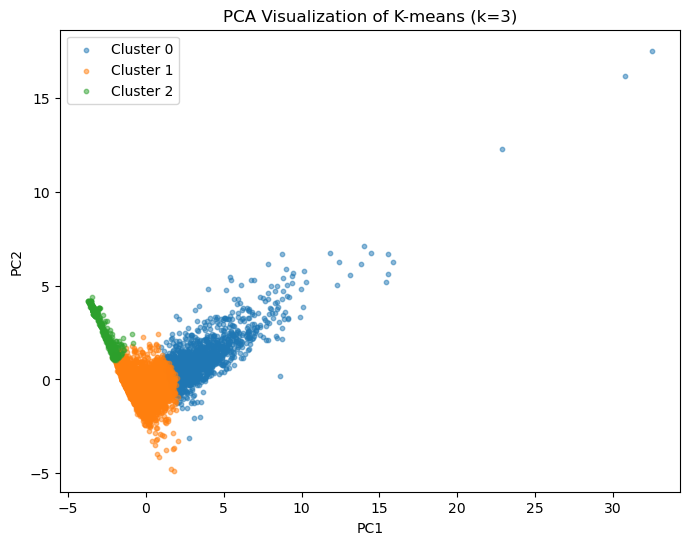

In [39]:
plt.figure(figsize=(8,6))
for c in sorted(pca_df["KMeans_3"].unique()):
    subset = pca_df[pca_df["KMeans_3"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], s=10, alpha=0.5, label=f"Cluster {c}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization of K-means (k=3)")
plt.legend()
plt.show()

Insight: 
For K-means (k=3), This gives the cleanest visible separation in 2D:
* one cluster sits mostly on the right / higher PC1 side
* one cluster is concentrated around the lower center
* one smaller cluster sits on the left / upper-left wedge

So visually, K-means k=3 gives a pretty clear low / medium / high style segmentation in PCA space.

**Plot 2: GMM full-6**

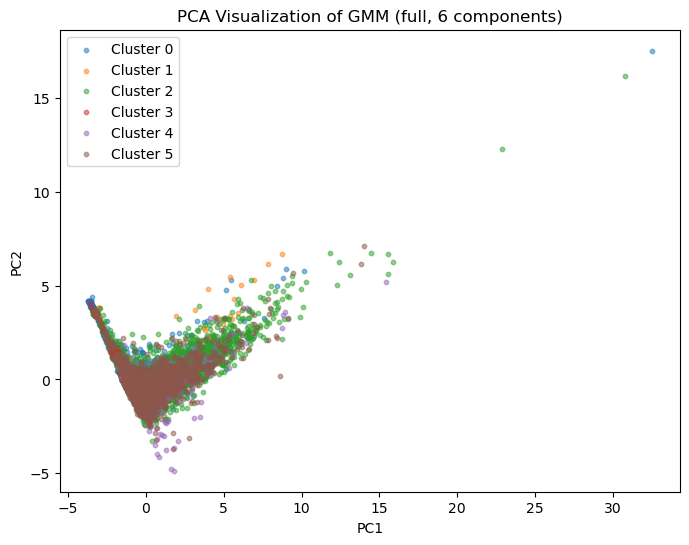

In [41]:
plt.figure(figsize=(8,6))
for c in sorted(pca_df["GMM_full_6"].unique()):
    subset = pca_df[pca_df["GMM_full_6"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], s=10, alpha=0.5, label=f"Cluster {c}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization of GMM (full, 6 components)")
plt.legend()
plt.show()

Insight: for GMM full-6, this looks the most overlapped in 2D. That does not mean it is bad — it means: the model is fitting structure in the full 75-dimensional space and seperation is happening outside this 2d view. This is actually consistent with why full-covariance GMM won on BIC: it is capturing more complex structure than a simple 2D picture can show.

**Plot 3:** GMM tied-6

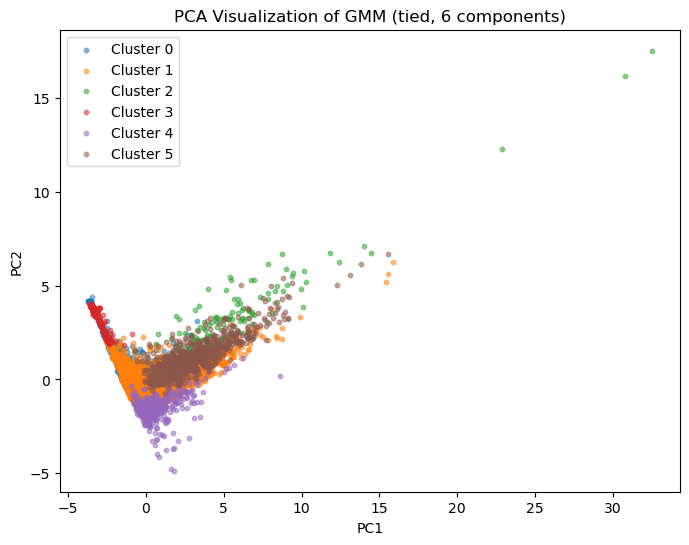

In [43]:
plt.figure(figsize=(8,6))
for c in sorted(pca_df["GMM_tied_6"].unique()):
    subset = pca_df[pca_df["GMM_tied_6"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], s=10, alpha=0.5, label=f"Cluster {c}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization of GMM (tied, 6 components)")
plt.legend()
plt.show()

Insight: For GMM tied-6, this looks like a middle ground. mosr structured than full-6 in the PCA view but still more nuanced than K-means.  I belived So visually, tied-6 is easier to explain than full-6.

In sum: K-means produced the cleanest visual split in PCA space, while the GMM models showed more overlap. However, because the PCA projection captures only part of the total variation, the visual overlap does not necessarily contradict the stronger statistical fit of the full-covariance GMM.

**Step 12: Build a summary table** 

In [54]:
summary_table = pd.DataFrame({
    "Model": [
        "K-means (k=2)",
        "K-means (k=3)",
        "GMM (full, 6)",
        "GMM (tied, 6)"
    ],
    "Selection basis": [
        "Highest silhouette among K-means",
        "Elbow support + interpretability",
        "Lowest BIC among GMM models",
        "Higher silhouette than full GMM + interpretability"
    ],
    "Metric value": [
        "Silhouette = 0.302",
        "Silhouette = 0.285",
        "BIC = -4.599e6",
        "BIC = -1.818e6; Silhouette = 0.245"
    ],
    "Interpretation": [
        "Best-separated K-means solution",
        "Most interpretable K-means segmentation",
        "Best statistical fit overall",
        "More interpretable GMM comparison model"
    ]
})

print(summary_table)

           Model                                    Selection basis  \
0  K-means (k=2)                   Highest silhouette among K-means   
1  K-means (k=3)                   Elbow support + interpretability   
2  GMM (full, 6)                        Lowest BIC among GMM models   
3  GMM (tied, 6)  Higher silhouette than full GMM + interpretabi...   

                         Metric value                           Interpretation  
0                  Silhouette = 0.302          Best-separated K-means solution  
1                  Silhouette = 0.285  Most interpretable K-means segmentation  
2                      BIC = -4.599e6             Best statistical fit overall  
3  BIC = -1.818e6; Silhouette = 0.245  More interpretable GMM comparison model  


References: 

Bishop, C. M. (2006). Pattern Recognition and Machine Learning. Springer.

Sakar, C. O., Polat, S. O., Katircioglu, M., & Kastro, Y. (2019). Real-time prediction of online shoppers’ purchasing intention using multilayer perceptron and LSTM recurrent neural networks. Neural Computing and Applications, 31, 6893–6908.